Problem Statement
---
You are part of a data science team at a commercial movie-streaming startup, “HamroMovies”. Your task is to build and evaluate a recommender system that increases user watch time and satisfaction through better movie suggestions.

---



We will use the MovieLens-100k Dataset, which contains lots of information. Please read the README file after downloading the dataset.

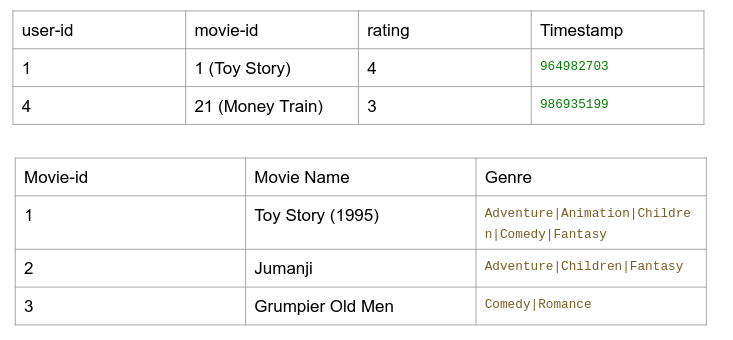

### 🎯 Milestone 1: Load and Explore the Dataset

Objective:

    Load MovieLens 100K, understand structure, and compute basic stats.

Given:

    Function to download the dataset

    Function to Load ratings.csv, movies.csv

    Function to count number of unique uers

    Function to count number of unique movies

    Function to calculate Percentage of user-movie pair for which rating is provided i.e. Rating sparsity

Tasks

    Understand the Dataset
      
      what information are provided in the dataset?
    
    Call the above functions to Compute:
    
      Number of Unique Users
      Number of Unique Movies
      Percentage of user-movie pair for which rating is provided i.e. Rating sparsity

Expected Output / Ground Truth:

✔ Number of users: 943  
✔ Number of movies: 1682  
✔ Rating sparsity: ~6.3%

In [8]:
# download movielens dataset
import os
import requests
import zipfile
import io

def download_movielens_dataset(url, extract_to='.'):
    """
    Downloads and extracts the MovieLens dataset from the given URL.

    Parameters:
    - url: str, URL to download the dataset from
    - extract_to: str, directory to extract the dataset files to
    """
    response = requests.get(url)
    if response.status_code == 200:
        with zipfile.ZipFile(io.BytesIO(response.content)) as z:
            z.extractall(extract_to)
        print(f"Dataset downloaded and extracted to {extract_to}")
    else:
        print(f"Failed to download dataset. Status code: {response.status_code}")


In [9]:
# load the movielens dataset using pandas
import pandas as pd

def load_movielens_data(directory='ml-100k'):
    """
    Loads the MovieLens dataset from the specified directory.

    Parameters:
    - directory: str, path to the directory containing the dataset files

    Returns:
    - ratings: DataFrame, contains user ratings
    """
    ratings_file = os.path.join(directory, 'u.data')
    if not os.path.exists(ratings_file):
        raise FileNotFoundError(f"Ratings file not found: {ratings_file}")

    ratings = pd.read_csv(ratings_file, sep='\t', names=['user_id', 'item_id', 'rating', 'timestamp'])
    return ratings

def load_movie_titles(directory='ml-100k'):
    """
    Loads the movie titles from the specified directory.

    Parameters:
    - directory: str, path to the directory containing the dataset files

    Returns:
    - movies: DataFrame, contains movie titles and their corresponding IDs
    """
    movies_file = os.path.join(directory, 'u.item')
    if not os.path.exists(movies_file):
        raise FileNotFoundError(f"Movies file not found: {movies_file}")

    movie_columns = ['item_id', 'title', 'release_date', 'video_release_date', '\
    imdb_url', 'unknown', 'action', 'adventure', 'animation', 'childrens', 'comedy',
    'crime', 'documentary', 'drama', 'fantasy', 'film_noir', 'horror', 'musical',
    'mystery', 'romance', 'sci_fi', 'thriller', 'war', 'western']
    movies = pd.read_csv(movies_file, sep='|', names=movie_columns, encoding='latin-1')
    return movies

def get_id_from_name(movie_name):
    """
    Retrieves the ID of a movie based on its name.

    Parameters:
    - movie_name: str, name of the movie

    Returns:
    - movie_id: int, ID of the movie
    """
    movie_id = movie_titles[movie_titles['title'] == movie_name]['item_id'].values[0]
    return int(movie_id)


In [10]:
def pivot_ratings_to_matrix(ratings):
  """
  Pivots the ratings DataFrame to create a user-item matrix.

  Parameters:
  - ratings: DataFrame, contains user ratings

  Returns:
  - user_item_matrix: dict, where keys are user IDs and values are dicts of item IDs and their ratings
  """
  user_item_matrix = ratings.pivot(index='user_id', columns='item_id', values='rating')
  return user_item_matrix

In [11]:
def count_users(ratings):
    """
    Counts the number of unique users in the ratings data.

    Parameters:
    - ratings: list of tuples, user-item-rating data

    Returns:
    - num_users: int, number of unique users
    """
    users = set(user_id for user_id, _, _, _ in ratings)
    return len(users)

def count_movies(ratings):
    """
    Counts the number of unique movies in the ratings data.

    Parameters:
    - ratings: list of tuples, user-item-rating data

    Returns:
    - num_movies: int, number of unique movies
    """
    movies = set(item_id for _, item_id, _, _ in ratings)
    return len(movies)

In [12]:
# what percentage of the user-item matrix is filled with ratings?
def calculate_sparsity(ratings, num_users=943, num_items=1682):
    """
    Calculates the sparsity of the user-item matrix.

    Parameters:
    - ratings: list of tuples, user-item-rating data
    - num_users: int, total number of users
    - num_items: int, total number of items

    Returns:
    - sparsity_percentage: float, percentage of the matrix filled with ratings
    """
    total_entries = num_users * num_items
    filled_entries = len(ratings)

    sparsity_percentage = (filled_entries / total_entries) * 100
    return sparsity_percentage

In [13]:
# TODO: Your code goes here
"""
Call the above functions to
  Download the dataset
  Load the dataset

Compute:
  Number of Unique Users
  Number of Unique Movies
  Percentage of user-movie pair for which rating is provided i.e. Rating sparsity
"""
url = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
download_movielens_dataset(url=url)
# load the data
ratings = load_movielens_data(directory='ml-100k') # pandas dataframe
print(ratings.describe())
ratings.head(n=10)
ratings.tail(n=10)


Dataset downloaded and extracted to .


In [22]:
print(f"the global average mu is {ratings['rating'].mean()}")
# user id 806 b_u : average rating given by user id b_u = 806
user_id = 806
print(f"user {user_id} rating bias {ratings[ratings['user_id'] == 806]['rating'].mean()}")
item_id = 242
print(f"Item {item_id} has bias {ratings[ratings['item_id'] == item_id].rating.mean()}")

the global average mu is 3.52986
user 806 rating bias 3.642857142857143
Item 242 has bias 3.9914529914529915


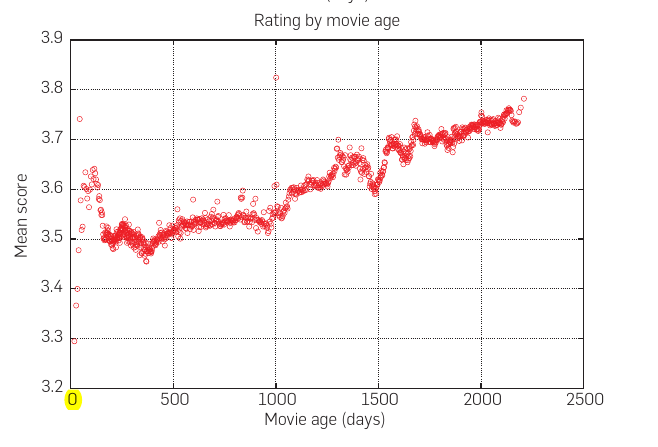

In [50]:
item_id = 242
# filtering by item_id
ratings_for_item_id = ratings[ratings['item_id'] == item_id]
ratings_for_item_id = ratings_for_item_id.sort_values(by='timestamp')
# task: define initial timestamp as 0, last timestamp as 100
# divide this time into 20 buckets of equal interval
# average the rating (mean score) and plot this rating on y-axis, x-axis as bucket_id
min_timestamp = ratings_for_item_id['timestamp'].min()
max_timestamp = ratings_for_item_id['timestamp'].max()
min_x_value, max_x_value = 0, 100
num_buckets = 20
bucket_width = (max_timestamp - min_timestamp) / num_buckets
# ratings with timestamp within a given range
x_values = []
y_values = []
r_for_id = ratings_for_item_id
for i in range(1,num_buckets):
  r_for_id_i = r_for_id[np.where(r_for_id['timestamp']>= min_timestamp+(i-1)*bucket_width)
        and (r_for_id['timestamp'] <= min_timestamp+i*bucket_width)]
  mean_score = r_for_id_i['rating'].mean()
  y_values.append(mean_score)
  x_values.append(min_timestamp + (i-1)*bucket_width)


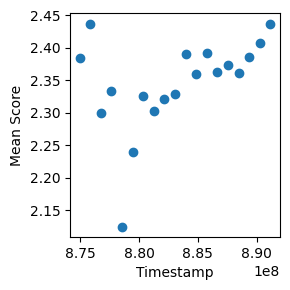

In [49]:

# plot x-axis time, y-axis mean score
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(3,3))
x,y = x_values, y_values
plt.scatter(x,y)
plt.xlabel('Timestamp')
plt.ylabel('Mean Score')
plt.tight_layout()
plt.show()


In [ ]:
# item_id 242 over time
item_id = 242
item_ratings = ratings['item_id'] ==

### TODO: What do the various columns in the ratings data mean?
Answer:

In [ ]:
movie_titles.head(5)

,item_id,title,release_date,video_release_date,imdb_url,unknown,action,adventure,animation,childrens,...,fantasy,film_noir,horror,musical,mystery,romance,sci_fi,thriller,war,western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
# count number of users, movies, and rating sparsity


Number of users: 943
Number of movies: 1682
Rating sparsity: 93.70%


### 🎯 Milestone 2: Baseline Solutions - What movie to recommend?
Naive / Baselines
Trending, Highly rated, Highly viewed, highly shared


🎯 Objective

Before building personalized recommendation models, it’s important to understand and implement baseline recommenders. These are simple, non-personalized approaches that serve as:

    Quick ways to generate useful suggestions,

    Benchmarks for evaluating model-based approaches,

    Production-ready solutions when user data is sparse.

In this milestone, you’ll build naive recommenders based on aggregate popularity, average ratings, and trending frequency using the MovieLens dataset.


📦 Dataset Prerequisite

Ensure you’ve loaded the MovieLens 100K or 1M dataset and merged:

    ratings.csv → contains userId, movieId, rating, timestamp

    movies.csv → contains movieId, title, genres

You'll use only this data — no personalization or machine learning yet.

🔨 Tasks


🧩 Task 1: Top-N Most Popular Movies (By Rating Count)

Goal: Recommend movies that have been watched the most.
```python
# Hint: Count how many times each movie appears in the ratings dataset
```
- Show top 10 movies by total number of ratings.

- Join with movies.csv to display their titles.


🧩 Task 2: Top-N Best Rated Movies (By Average Rating)

Goal: Recommend the highest-rated movies.

```python
# Hint: Use groupby to calculate mean rating per movie
```
- Filter to include only movies with at least 50 ratings to avoid statistical noise.

- Display top 10 movies by average rating.

🧩 Task 2.5: Top-N Highly rated Popular Movies (atleast rated better than 3.0 on average and is rated a lot of time)
```python
# Hint: find the average rating for each movies
- filter the movies based on average rating >= threshold (t)
- count the number of times this movie is rated
- sort in descending order and obtain top N movies
- obtain corresponding movie titles
```

🧩 Task 3: Trending Movies (Recently Popular)

Goal: Recommend movies that were most active in the last 30 days of the dataset.

```python
# Hint: Use timestamps to filter recent ratings
```

- Count how many ratings each movie received in the recent window.

- Display the top 10 trending movies.

In [ ]:
# Top-10 most popular movies (by rating count)
# how many times each movie appears in the ratings dataset

# rename the last column name 'rating_count' of the obtained dataframe

# additionally, add column for number of times the movie has been rated
# join the highest_occuring_movieIds with the movie_titles


,rating_count,title,release_date,video_release_date,imdb_url,unknown,action,adventure,animation,childrens,...,fantasy,film_noir,horror,musical,mystery,romance,sci_fi,thriller,war,western
item_id,,,,,,,,,,,,,,,,,,,,,
50,583,Star Wars (1977),01-Jan-1977,NaN,http://us.imdb.com/M/title-exact?Star%20Wars%2...,0,1,1,0,0,...,0,0,0,0,0,1,1,0,1,0
258,509,Contact (1997),11-Jul-1997,NaN,http://us.imdb.com/Title?Contact+(1997/I),0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
100,508,Fargo (1996),14-Feb-1997,NaN,http://us.imdb.com/M/title-exact?Fargo%20(1996),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
181,507,Return of the Jedi (1983),14-Mar-1997,NaN,http://us.imdb.com/M/title-exact?Return%20of%2...,0,1,1,0,0,...,0,0,0,0,0,1,1,0,1,0
294,485,Liar Liar (1997),21-Mar-1997,NaN,http://us.imdb.com/Title?Liar+Liar+(1997),0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
286,481,"English Patient, The (1996)",15-Nov-1996,NaN,http://us.imdb.com/M/title-exact?English%20Pat...,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
288,478,Scream (1996),20-Dec-1996,NaN,http://us.imdb.com/M/title-exact?Scream%20(1996),0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
1,452,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
300,431,Air Force One (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?Air+Force+One...,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
# TODO: Your Code goes here
"""
🧩 Task 2: Top-N Best Rated Movies (By Average Rating)

Goal: Recommend the highest-rated movies.
# Hint: Use groupby to calculate mean rating per movie

Filter to include only movies with at least 50 ratings to avoid statistical noise.

Display top 10 movies by average rating.

"""


# obtain rating count of item_id's i.e. how many times each movie appears in the rating dataset


# join avg_ratings and rating_count


# add movie title to the joint_avg_ratings_rating_count by joining with movie titles, keep only the movie titles from the movie_titles dataframe



item_id
1189    5.0
1500    5.0
1201    5.0
1293    5.0
1653    5.0
       ... 
1618    1.0
1626    1.0
784     1.0
852     1.0
858     1.0
Name: avg_rating, Length: 1682, dtype: float64
item_id
1       452
2       131
3        90
4       209
5        86
       ... 
1678      1
1679      1
1680      1
1681      1
1682      1
Name: rating_count, Length: 1682, dtype: int64


,avg_rating,rating_count,title,release_date,video_release_date,imdb_url,unknown,action,adventure,animation,...,fantasy,film_noir,horror,musical,mystery,romance,sci_fi,thriller,war,western
item_id,,,,,,,,,,,,,,,,,,,,,
408,4.491071,112,"Close Shave, A (1995)",28-Apr-1996,NaN,http://us.imdb.com/M/title-exact?Close%20Shave...,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
318,4.466443,298,Schindler's List (1993),01-Jan-1993,NaN,http://us.imdb.com/M/title-exact?Schindler's%2...,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
169,4.466102,118,"Wrong Trousers, The (1993)",01-Jan-1993,NaN,http://us.imdb.com/M/title-exact?Wrong%20Trous...,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
483,4.456790,243,Casablanca (1942),01-Jan-1942,NaN,http://us.imdb.com/M/title-exact?Casablanca%20...,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
114,4.447761,67,Wallace & Gromit: The Best of Aardman Animatio...,05-Apr-1996,NaN,http://us.imdb.com/Title?Wallace+%26+Gromit%3A...,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
64,4.445230,283,"Shawshank Redemption, The (1994)",01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Shawshank%20R...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
603,4.387560,209,Rear Window (1954),01-Jan-1954,NaN,http://us.imdb.com/M/title-exact?Rear%20Window...,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
12,4.385768,267,"Usual Suspects, The (1995)",14-Aug-1995,NaN,http://us.imdb.com/M/title-exact?Usual%20Suspe...,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
50,4.358491,583,Star Wars (1977),01-Jan-1977,NaN,http://us.imdb.com/M/title-exact?Star%20Wars%2...,0,1,1,0,...,0,0,0,0,0,1,1,0,1,0


In [ ]:
# TODO: Your code goes here
"""
🧩 Task 3: Trending Movies (Recently Popular)

Goal: Recommend movies that were most active in the last 30 days of the dataset.

# Hint: Use timestamps to filter recent ratings

Count how many ratings each movie received in the recent window.

Display the top 10 trending movies.

"""
# Hint: Use timestamps to filter recent ratings

print(f"Latest time: {latest_time}")
print(f"Recent window: {recent_window}")

print(f"Number of ratings in recent window: {len(recent_ratings)}")

# count how many ratings each movie received in the recent window

# sort in descending order

# join with movie_titles to obtain movie title for the item_id


Latest time: 1998-04-22 23:10:38
Recent window: 1998-03-23 23:10:38
Number of ratings in recent window: 16787
item_id
1       62
2       18
3        7
4       29
5       10
        ..
1669     1
1670     1
1672     1
1673     1
1674     1
Name: rating_count, Length: 1411, dtype: int64
item_id
313     115
258      98
300      95
286      93
269      93
       ... 
1666      1
1665      1
1663      1
1662      1
1658      1
Name: rating_count, Length: 1411, dtype: int64


,rating_count,title,release_date,video_release_date,imdb_url,unknown,action,adventure,animation,childrens,...,fantasy,film_noir,horror,musical,mystery,romance,sci_fi,thriller,war,western
item_id,,,,,,,,,,,,,,,,,,,,,
313,115,Titanic (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?imdb-title-12...,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
258,98,Contact (1997),11-Jul-1997,NaN,http://us.imdb.com/Title?Contact+(1997/I),0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
300,95,Air Force One (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?Air+Force+One...,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
286,93,"English Patient, The (1996)",15-Nov-1996,NaN,http://us.imdb.com/M/title-exact?English%20Pat...,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
269,93,"Full Monty, The (1997)",01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?Full+Monty%2C...,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
50,89,Star Wars (1977),01-Jan-1977,NaN,http://us.imdb.com/M/title-exact?Star%20Wars%2...,0,1,1,0,0,...,0,0,0,0,0,1,1,0,1,0
272,83,Good Will Hunting (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?imdb-title-11...,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
100,77,Fargo (1996),14-Feb-1997,NaN,http://us.imdb.com/M/title-exact?Fargo%20(1996),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
288,76,Scream (1996),20-Dec-1996,NaN,http://us.imdb.com/M/title-exact?Scream%20(1996),0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0


In [ ]:
# TODO: Your code goes here
"""
🧩 Task 4: Most Shared or Mentioned Movies (Simulated)

MovieLens doesn't contain social data. Simulate a “shared” metric by:

    Combining high rating and high view count.

    Create a synthetic "score" = avg_rating * log(num_ratings)
"""
# combine high rating and high view count
import numpy as np




,avg_rating,rating_count,title,release_date,video_release_date,imdb_url,unknown,action,adventure,animation,...,film_noir,horror,musical,mystery,romance,sci_fi,thriller,war,western,score
item_id,,,,,,,,,,,,,,,,,,,,,
50,4.358491,583,Star Wars (1977),01-Jan-1977,NaN,http://us.imdb.com/M/title-exact?Star%20Wars%2...,0,1,1,0,...,0,0,0,0,1,1,0,1,0,27.755684
100,4.155512,508,Fargo (1996),14-Feb-1997,NaN,http://us.imdb.com/M/title-exact?Fargo%20(1996),0,0,0,0,...,0,0,0,0,0,0,1,0,0,25.890839
127,4.283293,413,"Godfather, The (1972)",01-Jan-1972,NaN,"http://us.imdb.com/M/title-exact?Godfather,%20...",0,1,0,0,...,0,0,0,0,0,0,0,0,0,25.800191
174,4.252381,420,Raiders of the Lost Ark (1981),01-Jan-1981,NaN,http://us.imdb.com/M/title-exact?Raiders%20of%...,0,1,1,0,...,0,0,0,0,0,0,0,0,0,25.685464
98,4.289744,390,"Silence of the Lambs, The (1991)",01-Jan-1991,NaN,http://us.imdb.com/M/title-exact?Silence%20of%...,0,0,0,0,...,0,0,0,0,0,0,1,0,0,25.593240
318,4.466443,298,Schindler's List (1993),01-Jan-1993,NaN,http://us.imdb.com/M/title-exact?Schindler's%2...,0,0,0,0,...,0,0,0,0,0,0,0,1,0,25.445743
64,4.445230,283,"Shawshank Redemption, The (1994)",01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Shawshank%20R...,0,0,0,0,...,0,0,0,0,0,0,0,0,0,25.095308
181,4.007890,507,Return of the Jedi (1983),14-Mar-1997,NaN,http://us.imdb.com/M/title-exact?Return%20of%2...,0,1,1,0,...,0,0,0,0,1,1,0,1,0,24.963184
313,4.245714,350,Titanic (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?imdb-title-12...,0,1,0,0,...,0,0,0,0,1,0,0,0,0,24.871110


### 🎯 Milestone: Construct Utility Matrix and Compute Item Similarity

Objective: Create user–item matrix and compute item–item cosine similarity

Tasks:

    Pivot table to create user–item utility matrix

    Fill NaN with 0 (for similarity)

    Compute cosine similarity between items

Ground Truth (checkpoints):

    Shape of utility matrix: (943, 1682)

    Type: Pandas DataFrame or NumPy array

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
def compute_item_similarity(user_item_matrix):
  """
  Computes the cosine similarity between items in the user-item matrix.

  Parameters:
  - user_item_matrix: dict, where keys are user IDs and values are dicts of item IDs and their ratings

  Returns:
  - item_similarity: DataFrame, cosine similarity matrix between items
  """
  user_item_matrix = pd.DataFrame(user_item_matrix).fillna(0)
  item_similarity = pd.DataFrame(cosine_similarity(user_item_matrix.T), index=user_item_matrix.columns, columns=user_item_matrix.columns)
  return item_similarity

In [ ]:

item_sim = compute_item_similarity(pivot_ratings_to_matrix(ratings))

In [ ]:
item_sim.head(5)

item_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
item_id,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.402382,0.330245,0.454938,0.286714,0.116344,0.620979,0.481114,0.496288,0.273935,...,0.035387,0.0,0.000000,0.000000,0.035387,0.0,0.0,0.0,0.047183,0.047183
2,0.402382,1.000000,0.273069,0.502571,0.318836,0.083563,0.383403,0.337002,0.255252,0.171082,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.078299,0.078299
3,0.330245,0.273069,1.000000,0.324866,0.212957,0.106722,0.372921,0.200794,0.273669,0.158104,...,0.000000,0.0,0.000000,0.000000,0.032292,0.0,0.0,0.0,0.000000,0.096875
4,0.454938,0.502571,0.324866,1.000000,0.334239,0.090308,0.489283,0.490236,0.419044,0.252561,...,0.000000,0.0,0.094022,0.094022,0.037609,0.0,0.0,0.0,0.056413,0.075218
5,0.286714,0.318836,0.212957,0.334239,1.000000,0.037299,0.334769,0.259161,0.272448,0.055453,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.094211


### 🎯 Milestone 3: Item-Based Recommendation Function

Objective: Recommend Top-N movies based on rated movies and similarity matrix

Tasks:
    Recommend Top-5 movies for a sample user (e.g., userId=10)

Ground Truth:

    Function: recommend_item_based(user_id, top_n)

    Output:

recommend_item_based(10, 5) → returns 5 movie titles not yet rated by user 10

    Manual check:

        Recommended movies should not be in the user's rated list

        Movies should have high similarity to at least one rated movie

In [ ]:
# recommend top-N similar movies to a liked movie
def recommend_similar_movies(liked_movie, item_similarity, num_recommendations=5):
  """
  Recommends similar movies based on the cosine similarity of liked movies.

  Parameters:
  - liked_movie: str, the name of the liked movie
  - item_similarity: DataFrame, cosine similarity matrix between items
  - num_recommendations: int, number of similar movies to recommend

  Returns:
  - similar_movies: list of str, names of the recommended similar movies
  """
  # if liked movie is a string, get the movie id
  if isinstance(liked_movie, str):
    liked_movie = get_id_from_name(liked_movie)

  if liked_movie not in item_similarity.index:
    raise ValueError(f"Liked movie '{liked_movie}' not found in the item similarity matrix.")

  sim_scores = item_similarity[liked_movie]
  sim_scores = sim_scores.sort_values(ascending=False)
  similar_movies = sim_scores.index[1:num_recommendations+1].tolist()
  # get name of movies from id's
  similar_movies_titles = [movie_titles[movie_titles['item_id'] == movie_id]['title'].values[0] for movie_id in similar_movies]
  return similar_movies, similar_movies_titles

In [ ]:
movie_title = 'Toy Story (1995)'
_, recommended_movies = recommend_similar_movies(liked_movie=movie_title, item_similarity=item_sim)
print(f"Recommended movies for '{movie_title}': {recommended_movies}")

Recommended movies for 'Toy Story (1995)': ['Star Wars (1977)', 'Return of the Jedi (1983)', 'Independence Day (ID4) (1996)', 'Rock, The (1996)', 'Mission: Impossible (1996)']


In [ ]:
# find recommendations for 5 random movies in the movie titles
import random
random_movies = random.sample(list(movie_titles['title']), 15)
for movie in random_movies:
  _, recommended_movies = recommend_similar_movies(liked_movie=movie, item_similarity=item_sim)
  print(f"Recommended movies for '{movie}': {recommended_movies}")

Recommended movies for 'Some Like It Hot (1959)': ["Singin' in the Rain (1952)", 'Apartment, The (1960)', 'Vertigo (1958)', 'Casablanca (1942)', 'Chinatown (1974)']
Recommended movies for 'Cérémonie, La (1995)': ['Neon Bible, The (1995)', "Ed's Next Move (1996)", 'Rendezvous in Paris (Rendez-vous de Paris, Les) (1995)', "Enfer, L' (1994)", 'Big One, The (1997)']
Recommended movies for 'Piano, The (1993)': ['Four Weddings and a Funeral (1994)', 'Amadeus (1984)', 'Like Water For Chocolate (Como agua para chocolate) (1992)', '2001: A Space Odyssey (1968)', 'Fried Green Tomatoes (1991)']
Recommended movies for 'Thirty-Two Short Films About Glenn Gould (1993)': ['Two or Three Things I Know About Her (1966)', 'Ice Storm, The (1997)', '8 1/2 (1963)', 'Daytrippers, The (1996)', 'Crumb (1994)']
Recommended movies for 'Ninotchka (1939)': ['Notorious (1946)', 'Top Hat (1935)', 'Gaslight (1944)', 'To Catch a Thief (1955)', 'His Girl Friday (1940)']
Recommended movies for 'One Night Stand (1997)': 